# Earth

SPEEDY T31L8, built with realistic topography 

## Build it

In [2]:
from pathlib import Path

from jem import plot

output_dir = (Path("output") / "01-05_Earth_wet").resolve()
output_dir.mkdir(parents=True, exist_ok=True)

This next cell is the direct construction: a plain `jcm.model.Model`
wrapped as a component, a `SlabGrid` taken from the atmosphere's own
horizontal grid, and a `Coupler` wiring them (plus the sea-ice and land
components below) with a hand-written exchanger function -- the pattern
`01_aquaplanet.ipynb` uses -- rather than the standard exchange table.
Apart from that exchanger it is identical to
`docs/source/python_api.md`'s own quick-start block, up to and including
`print(repr(coupler))` -- pinned byte for byte by
`tests/unit/test_notebook_construction.py` -- except for four
substitutions: the import and `components` entry `SlabSeaiceModel` needs,
the explicit `time_step=12` the `Model(...)` call needs (see the comment
above it in the next cell for why), and -- the one that makes this notebook
an *Earth* example rather than another aquaplanet -- a real `TerrainData`
built from jax-gcm's own cached T31 terrain file
(`generate_jcm_forcing_and_topography_files`, which generates it under
`~/.cache/jcm` the first time it is needed and reuses the cached copy after,
with no network access), so the atmosphere sees actual orography and a real
land-sea mask instead of the all-zero, all-ocean default `Model(...)` falls
back to with no `terrain` argument. `SlabGrid` is built from that same
`fmask` (read back off the already-constructed atmosphere, not re-derived)
so the land model and the atmosphere agree on where the continents are.
`python_api.md`'s own block stops at the atmosphere and the ocean (the
smallest coupled pair worth showing); this run also couples the slab
sea-ice and land models, so it is added here to keep this notebook honest
about what it actually runs -- an ocean alone has nowhere to put the
freeze/melt energy `SlabOceanModel` reports once its mixed layer reaches
the freezing point, and that energy would be silently dropped without the
sea-ice component.

In [2]:
import jax_datetime as jdt
import jcm
from jcm.physics.speedy.speedy_coords import get_speedy_coords
from jcm.terrain import TerrainData

from jem import Coupler, run_chunked
from jem.components import (
    JCMComponent,
    SlabBucketLandModel,
    SlabBucketLandParameters,
    SlabOceanModel,
    SlabSeaiceModel,
)
from jem.components.slab import SlabGrid
from jem.tool_scripts.generate_jcm_forcing_and_topography_files import (
    generate_jcm_forcing_and_topography_files,
)

start_date = jdt.to_datetime("2000-01-01")
coupling_timestep = jdt.to_timedelta(1, "day")

coords = get_speedy_coords()

# Real orography and a real land-sea mask, rather than the all-zero,
# all-ocean default `Model(...)` falls back to with no `terrain` argument.
# `generate_jcm_forcing_and_topography_files` is jax-gcm's own cache: it
# returns the T31 terrain/forcing files under `~/.cache/jcm`, generating
# them there (from the packaged raw boundary data, offline) the first time
# they are needed and reusing the cached copy every time after.
jcm_files = generate_jcm_forcing_and_topography_files(resolution=31)
terrain = TerrainData.from_file(jcm_files["terrain"], coords)

# The JCM atmosphere: a plain jcm.model.Model, wrapped as a component.
# `time_step=12` (minutes) is the step `+configuration=earth-slab`
# actually runs at -- jax-gcm's `run/default.yaml`, composed at
# `atmosphere.run.time_step` -- and has to be given explicitly: with no
# `time_step`, `Model` instead picks the physics' own stable step (30
# minutes for SPEEDY T31L8), a materially different model than the one
# this notebook claims to reproduce.
atm_model = jcm.model.Model(
    coords=coords, start_time=start_date, time_step=12, terrain=terrain
)
atm = JCMComponent(atm_model)

# Earth: the slab grid is built from the atmosphere's own horizontal grid
# *and* the same `fmask` the atmosphere's terrain carries -- read back off
# the already-built model rather than re-derived -- so the land model and
# the atmosphere can never disagree about where the continents are.
grid = SlabGrid.from_coords(atm_model.coords.horizontal, atm_model.terrain.fmask)

# An exchanger is the only place where components exchange information: a
# plain function from the coupled carry (and the coupling time) to a new
# coupled carry. This one is written out by hand, the same pattern
# `01_aquaplanet.ipynb` uses, with the land model's rows added.
components = {
    "atm": atm,
    "ocn": SlabOceanModel(grid),
    "seaice": SlabSeaiceModel(grid, name="seaice"),
    "lnd": SlabBucketLandModel(grid, SlabBucketLandParameters(tdland=864000.0)),
}

# The full atmosphere/ocean/sea-ice/land loop:
#   - `ocn.state.sea_surface_temperature` -> `atm.forcing.sea_surface_temperature`
#     and -> `seaice.forcing.sea_surface_temperature` (the slab sea ice is
#     diagnosed from SST alone, so SST is the only thing it is handed)
#   - `seaice.state.ice_fraction` -> `atm.forcing.sice_am` (the ice cover the
#     atmosphere's surface-flux scheme sees)
#   - `atm.derived.total_heat_flux` -> `ocn.forcing.total_heat_flux` and
#     -> `lnd.forcing.total_heat_flux` (JCM's net surface heat flux, upward
#     positive, already sign-converted from JCM's own downward-positive
#     convention by the JCM wrapper). Ocean and land get the same field
#     because all four components share one grid; each applies its own
#     land-sea mask.
#   - `atm.derived.precipitation` -> `lnd.forcing.precipitation` (total
#     precipitation reaching the surface, kg m-2 s-1, positive downward:
#     the only source of water the bucket land model's top soil layer has,
#     so without this row its soil moisture just drains away)
#   - `lnd.state.land_surface_temperature` -> `atm.forcing.stl_am`,
#     `lnd.state.snowc` -> `atm.forcing.snowc_am` and the top layer of
#     `lnd.state.soilw` -> `atm.forcing.soilw_am` (the land surface the
#     atmosphere's surface-flux scheme sees; the bucket model's soil water
#     has a trailing layer axis, and the surface layer, index 0, is the one
#     in contact with the atmosphere)
def exchanger(cpl_carry, time):
    atm = cpl_carry["atm"]
    ocn = cpl_carry["ocn"]
    seaice = cpl_carry["seaice"]
    lnd = cpl_carry["lnd"]

    sea_surface_temperature = ocn["state"].sea_surface_temperature
    total_heat_flux = atm["derived"].total_heat_flux
    ice_fraction = seaice["state"].ice_fraction

    atm = dict(atm, forcing=atm["forcing"].replace(
        sea_surface_temperature=sea_surface_temperature,
        sice_am=ice_fraction,
        stl_am=lnd["state"].land_surface_temperature,
        snowc_am=lnd["state"].snowc,
        soilw_am=lnd["state"].soilw[:, :, 0],
    ))
    ocn = dict(ocn, forcing=ocn["forcing"].replace(
        total_heat_flux=total_heat_flux,
    ))
    seaice = dict(seaice, forcing=seaice["forcing"].replace(
        sea_surface_temperature=sea_surface_temperature,
    ))
    lnd = dict(lnd, forcing=lnd["forcing"].replace(
        total_heat_flux=total_heat_flux,
        precipitation=atm["derived"].precipitation,
    ))

    return {**cpl_carry, "atm": atm, "ocn": ocn, "seaice": seaice, "lnd": lnd}


coupler = Coupler(
    components,
    {
        "exchanger": exchanger,
    },
    workflow=["exchanger", "atm", "ocn", "seaice", "lnd"],
    coupling_timestep=coupling_timestep,
    start_date=start_date,
)
print(repr(coupler))

/home/xtt/projects/project_jax-esm/jcm_repo/jax-gcm/jcm/data/bc/interpolate.py:105: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  return xr.merge([ds_interp, passthrough])


Coupler(name='coupled', components=['atm', 'ocn', 'seaice', 'lnd'], exchangers=['exchanger'], workflow=['exchanger', 'atm', 'ocn', 'seaice', 'lnd'], coupling_timestep=1 days, start_date='2000-01-01T00:00:00')


## Run it

In [3]:
result = run_chunked(
    coupler,
    total_time="180 days",
    chunk="30 days",
    output_dir=str(output_dir),
    subsample=3,       # 10 records out of 30 coupled days
    checkpoint_path=None,
)
result.steps_completed, [p.name for p in result.paths]

(180,
 ['atm-00000000.nc',
  'lnd-00000000.nc',
  'ocn-00000000.nc',
  'seaice-00000000.nc',
  'atm-00000030.nc',
  'lnd-00000030.nc',
  'ocn-00000030.nc',
  'seaice-00000030.nc',
  'atm-00000060.nc',
  'lnd-00000060.nc',
  'ocn-00000060.nc',
  'seaice-00000060.nc',
  'atm-00000090.nc',
  'lnd-00000090.nc',
  'ocn-00000090.nc',
  'seaice-00000090.nc',
  'atm-00000120.nc',
  'lnd-00000120.nc',
  'ocn-00000120.nc',
  'seaice-00000120.nc',
  'atm-00000150.nc',
  'lnd-00000150.nc',
  'ocn-00000150.nc',
  'seaice-00000150.nc'])

## What it wrote

One file per component per chunk, named after the coupled step its chunk starts on (`<component>-<first step>.nc`).

In [3]:
atm_ds = plot.open_output(output_dir, "atm")
ocn_ds = plot.open_output(output_dir, "ocn")
seaice_ds = plot.open_output(output_dir, "seaice")
lnd_ds = plot.open_output(output_dir, "lnd")
list(ocn_ds.data_vars)
list(lnd_ds.data_vars)

['land_surface_temperature',
 'snowc',
 'soilw',
 'forcing_total_heat_flux',
 'forcing_precipitation']

## Plot

All three coupled components show up below: surface specific humidity (animated -- the field this example's top-level README entry is named after) and sea surface temperature from the atmosphere and ocean, and ice thickness from the sea-ice component.

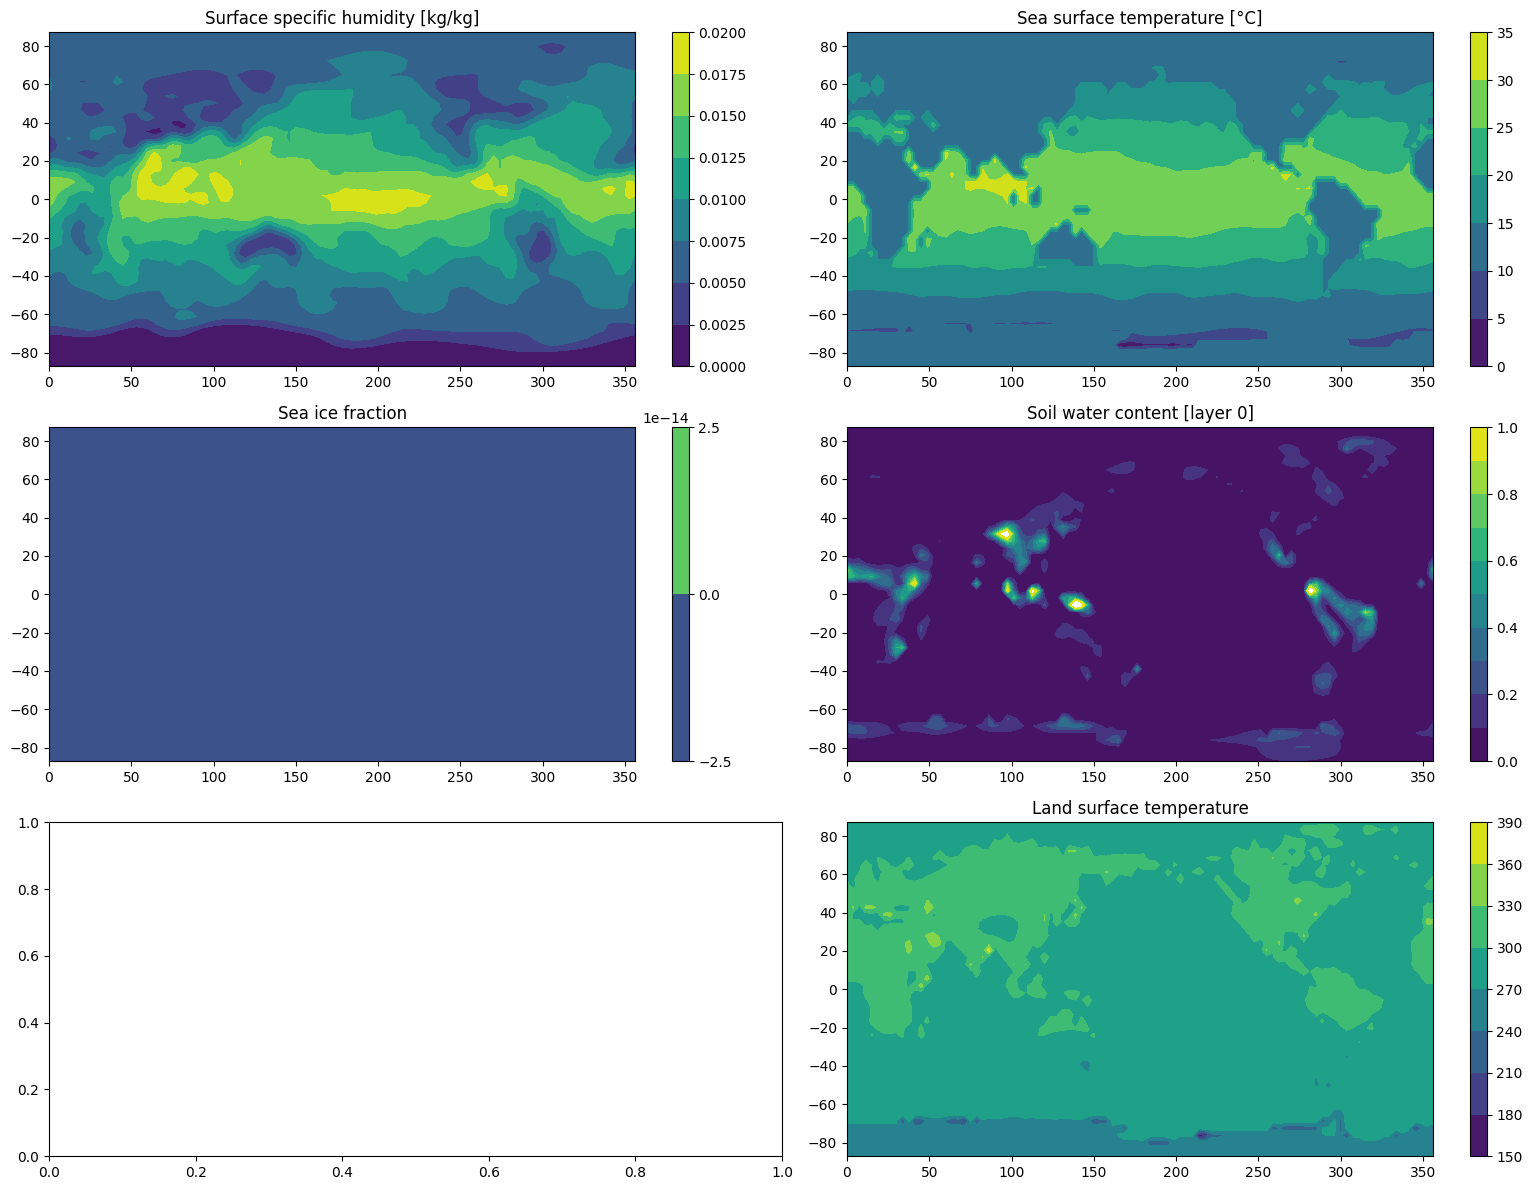

In [9]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# `level` is a sigma coordinate, surface-first, so selecting by its
# value (rather than `.isel(level=0)`) says so without relying on that
# ordering -- see "Output conventions" in
# docs/source/design/output.md.
humidity = atm_ds["specific_humidity"].sel(level=1.0, method="nearest")
plot.map_plot(humidity.isel(time=-1), ax=axes[0, 0],
              title="Surface specific humidity [kg/kg]")

sst = ocn_ds["sea_surface_temperature"].isel(time=-1) - 273.15
plot.map_plot(sst, ax=axes[0, 1], title="Sea surface temperature [°C]")

plot.map_plot(seaice_ds["ice_fraction"].isel(time=-1), ax=axes[1, 0],
              title="Sea ice fraction")

plot.map_plot(lnd_ds["soilw"].isel(time=-1, layer=0), ax=axes[1, 1], levels=np.linspace(0, 1, 11),
              title="Soil water content [layer 0]")

plot.map_plot(lnd_ds["land_surface_temperature"].isel(time=-1), ax=axes[2, 1],
              title="Land surface temperature")

plt.tight_layout()



In [ ]:
fig, ax = plt.subplots()
plot.area_mean(ocn_ds["sea_surface_temperature"]).plot(ax=ax)
ax.set_ylabel("Area-mean SST [K]")

# Animate the same field the static panel above shows, and the field
# the top-level README's gif is named after.
ani = plot.animate_map(humidity, title="Surface specific humidity [kg/kg]")
ani.save(output_dir / "specific_humidity.gif", writer="pillow")